In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red">ch07_ 라이브러리를 이용한 시계열 데이터 분석 </font>**
- statsmodels : 통계분석을 하기 위한 라이브러리(회귀분석, 시계열분석, 가설검정, 기술통계)
    * 주기적인 데이터의 트렌드 추이
- Prophet : 계절성 추세, 휴일효과 자동으로 모델링


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
#한글설정
plt.rc('font',family='Malgun Gothic')
plt.rc('axes',unicode_minus=False)

In [12]:
# data.go.kr/ 에어코리아(AirKorea) 다운로드
df=pd.read_csv('data/일별평균대기오염도_2022(에어코리아).csv',encoding='cp949')
df.tail()


,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
18245,20221231,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,광진구,0.026,0.005,0.8,0.003,44.0,34.0
18247,20221231,관악산,0.008,0.038,0.3,0.005,29.0,18.0
18248,20221231,관악구,0.045,0.009,0.7,0.003,42.0,28.0
18249,20221231,공항대로,0.042,0.007,0.7,0.004,41.0,31.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [20]:
# 결측치 있는 데이터
df[df['이산화질소농도(ppm)'].isna()] 
df[df.isna().any(axis=1)] # 결측치가 한열이라도 있는 경우를 출력
df.loc[df.isna().any(axis=1),'측정소명'].value_counts() #결측치가 한열이라도 있는 측정소명 
# len(df.loc[df.isna().any(axis=1),'측정소명'].value_counts()) # 21개 측정치가 결측치가 있음


21

In [26]:
#서울시 측정소 명들
print('측정소들:',df['측정소명'].nunique())
len(df['측정소명'].unique())

측정소들: 50


50

In [34]:
# 측정일시가 날짜타입이 아닌걸 확인함
# int형인 측정일시 컬럼을 str로 변형
df['측정일시']= df['측정일시'].astype(str)  # 측정일시를 문자타입으로 변경
df['측정일시']=pd.to_datetime(df['측정일시'])

In [36]:
df.info()  # 시계열 분석 가능 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  datetime64[ns]
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18172 non-null  float64       
 3   오존농도(ppm)     18176 non-null  float64       
 4   일산화탄소농도(ppm)  18174 non-null  float64       
 5   아황산가스농도(ppm)  18176 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.1+ MB


In [43]:
# 50개 측정소명을 매일 기록 (그중 결측치가 있을 수 있음)
df['측정소명'].value_counts().sort_index().index

Index(['강남구', '강남대로', '강동구', '강변북로', '강북구', '강서구', '공항대로', '관악구', '관악산', '광진구',
       '구로구', '금천구', '남산', '노원구', '도봉구', '도산대로', '동대문구', '동작구', '동작대로', '마포구',
       '마포아트센터', '북한산', '서대문구', '서울숲', '서초구', '성동구', '성북구', '세곡', '송파구',
       '시흥대로', '신촌로', '양천구', '영등포구', '영등포로', '올림픽공원', '용산구', '은평구', '자연사박물관',
       '정릉로', '종로', '종로구', '중구', '중랑구', '천호대로', '청계천로', '한강대로', '항동', '행주',
       '홍릉로', '화랑로'],
      dtype='object')

In [49]:
#미세먼지와 초미세먼지 컬럼에 결측치가 없는 측정소명 
df[df['측정소명']=='공항대로'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    datetime64[ns]
 1   측정소명          365 non-null    object        
 2   이산화질소농도(ppm)  365 non-null    float64       
 3   오존농도(ppm)     365 non-null    float64       
 4   일산화탄소농도(ppm)  365 non-null    float64       
 5   아황산가스농도(ppm)  365 non-null    float64       
 6   미세먼지농도(㎍/㎥)   365 non-null    float64       
 7   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 25.7+ KB


In [74]:
loc_name='공항대로' #관악구는 결측치가 있는 측정소명
df_flt= df[df['측정소명']==loc_name]


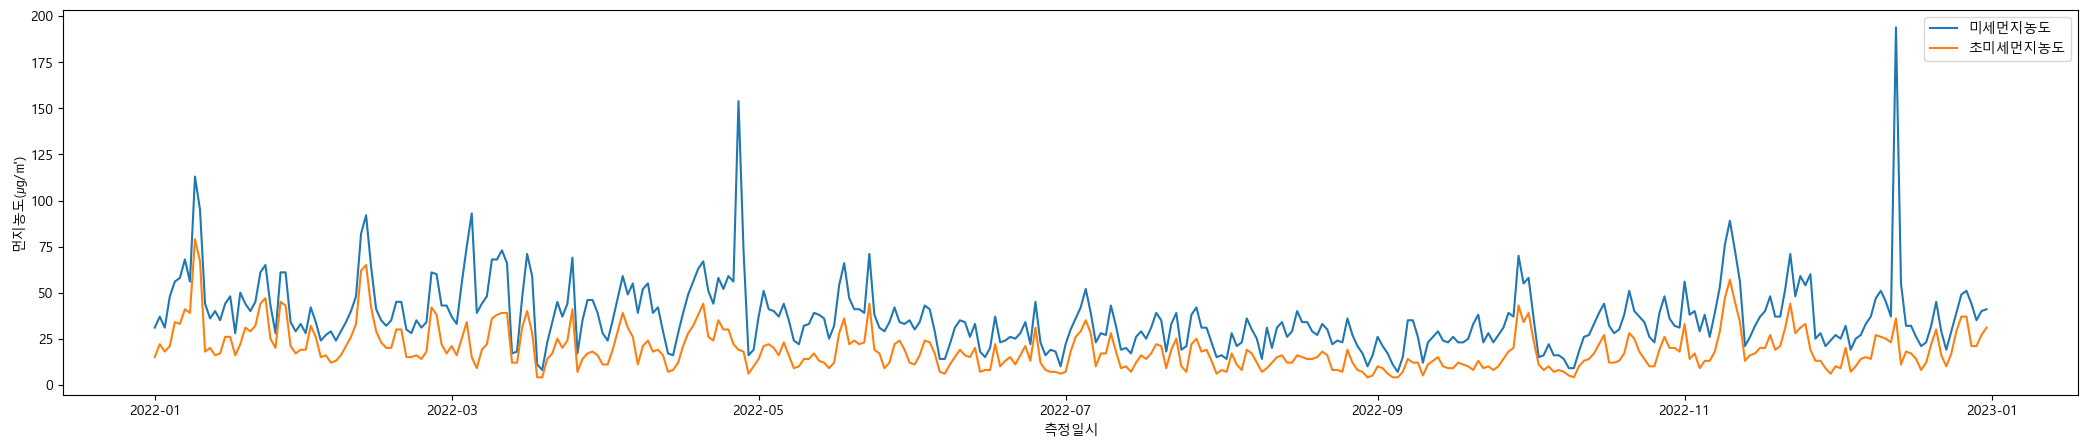

In [77]:
plt.figure(figsize=(26,5))
plt.plot(df_flt['측정일시'],df_flt['미세먼지농도(㎍/㎥)'],label='미세먼지농도')
plt.plot(df_flt['측정일시'],df_flt['초미세먼지농도(㎍/㎥)'],label='초미세먼지농도')
plt.xlabel('측정일시')
plt.ylabel('먼지농도(㎍/㎥)')
plt.legend()
plt.show()

In [ ]:
#statsmodels를 통한 추이 탐색

# statsmodels를 통한 추이 탐색
- pip install statsmodels==0.13.5
- 주기적인 데이터의 트렌드 추이
- 날짜형인덱스와 데이터 칼럼

In [66]:
df_flt2 =df_flt[['측정일시','미세먼지농도(㎍/㎥)']]
ts=df_flt2.set_index('측정일시') 
ts.head()

,미세먼지농도(㎍/㎥)
측정일시,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


In [67]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2022-01-01 to 2022-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   미세먼지농도(㎍/㎥)  365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [82]:
# 시계열 데이터의 구조를 분해 해주는 도구(statsmodels.tsa 시계열 분석 lib 패키지)
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                         period=30, # 30일 단위로 계절성을 분해해서 해석
                         model='additive' #실제값 =추세 +계절성 +잔차
                         )
#result.observed : 실제데이터
#result.trend #데이터의 장기적인 변화. 전반적으로 감소, 증가
#result.seasonal #주기적인 계절성 패턴
#result.resid # 잔차(실제값에서 추이와 계절성을 뺀 노이즈)

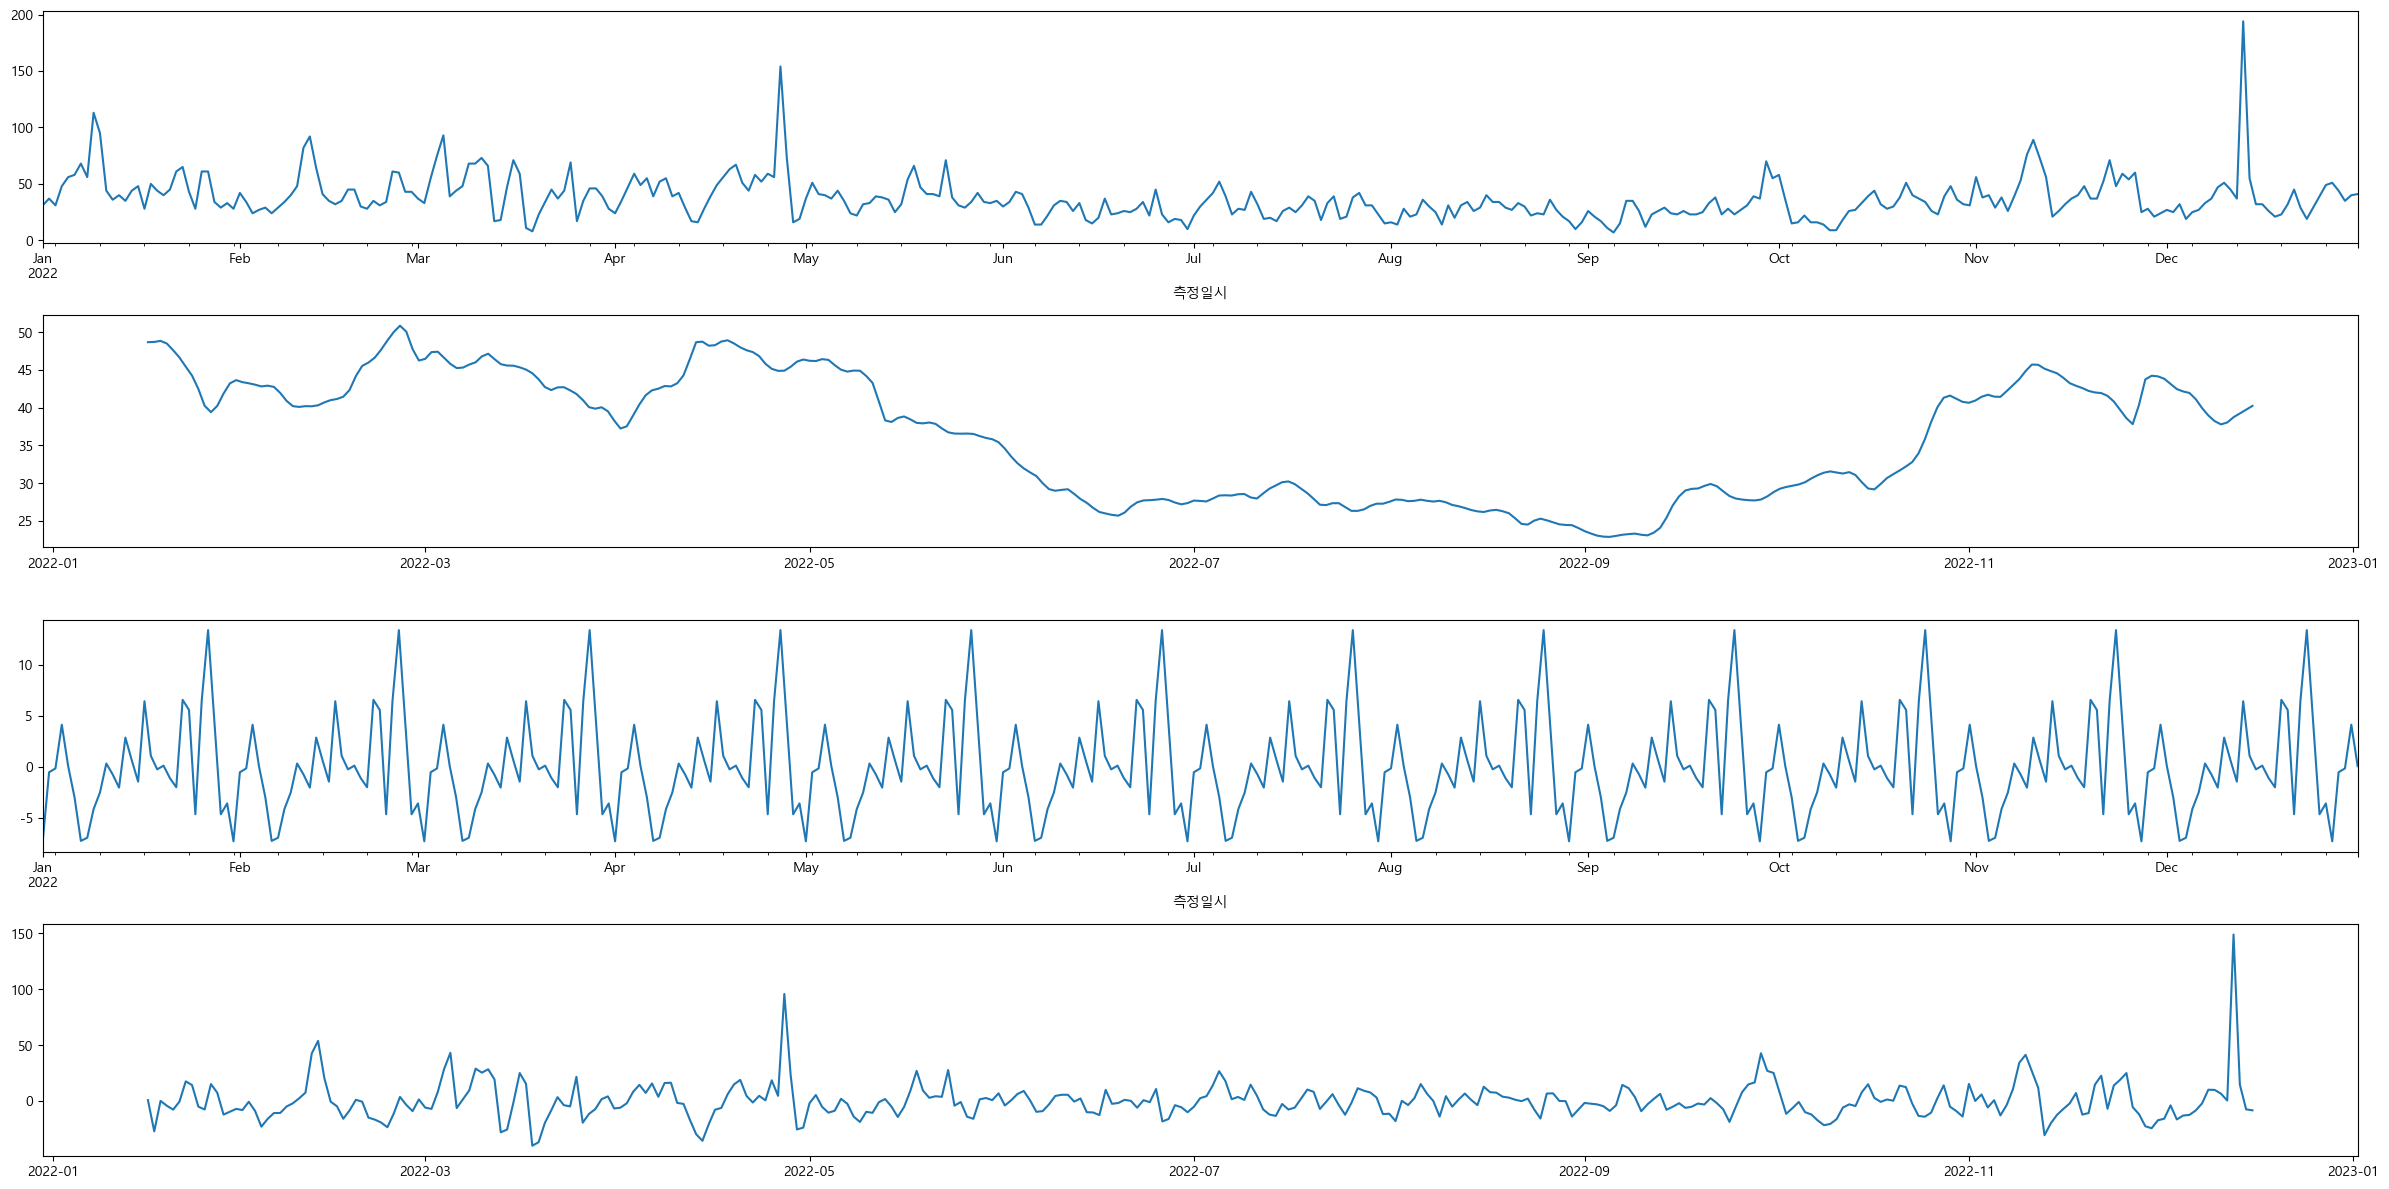

In [87]:
fig, axes =plt.subplots(nrows=4,ncols=1,
                       figsize=(24,12))
result.observed.plot(ax=axes[0])
axes[1].plot(result.trend)
result.seasonal.plot(ax=axes[2])
axes[3].plot(result.resid)
plt.tight_layout()
plt.show()

```
    seasonal_decompose & RNN / LSTM / GRU / Seq2Seq & Prophet
        통계적 추이 분석         예측                    추이&예측
```
# Prophet (예측)
- 계절성, 추이, 휴일효과 등을 자동으로 모델링(facebook에서 개발한 시계열 예측 라이브러리)
- pip install prophet

In [98]:
df_flt2.sample()

,측정일시,미세먼지농도(㎍/㎥)
9693,2022-07-13,20.0


In [102]:
df_flt2.columns = ['ds','y'] #prophet학습시 컬럼명을 ds, y로 해야 됨  ds는 날짜형 , y는 숫자형이어야함
df_flt2.sample()

,ds,y
1843,2022-02-06,24.0


In [103]:
df_flt2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      365 non-null    datetime64[ns]
 1   y       365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.6 KB


In [107]:
from prophet import Prophet
#1. 모델생성
p_model=Prophet()
#2. 모델학습
p_model.fit(df_flt2)

14:50:49 - cmdstanpy - INFO - Chain [1] start processing
14:50:49 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05
...,...
390,2023-01-26
391,2023-01-27
392,2023-01-28
393,2023-01-29


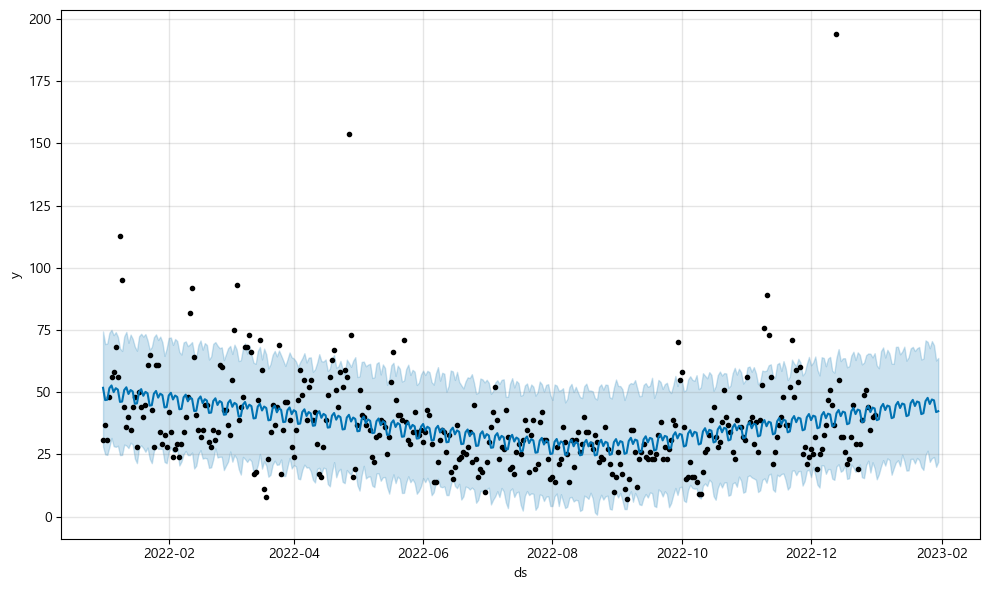

In [117]:
#p_model을 이용하여 30일 이후의 데이터를 예측하고 추이
# 3. 미래 데이터 프레임을 생성(30일 예측)
future = p_model.make_future_dataframe(periods=30)
display(future)
# 4. 예측 수행

forecast= p_model.predict(future)
forecast.tail(30)
# 5. 시각화
p= p_model.plot(forecast) #그래프를 한번만 그리려면 할당 해야함

In [114]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30)
#forecast : yhat을 추세 + 계절성 + 기타요인

,ds,yhat,yhat_lower,yhat_upper
365,2023-01-01,38.760344,16.662916,59.970060
366,2023-01-02,39.131423,17.701223,60.633649
367,2023-01-03,44.001296,21.867100,68.271144
368,2023-01-04,45.309448,23.089480,66.595567
369,2023-01-05,42.843737,19.726455,64.273250
370,2023-01-06,44.648279,21.462254,65.155311
371,2023-01-07,44.295943,21.509600,66.935065
372,2023-01-08,39.573621,18.137562,63.939979
373,2023-01-09,39.944700,17.652244,62.559554
374,2023-01-10,44.814573,24.124904,65.855111


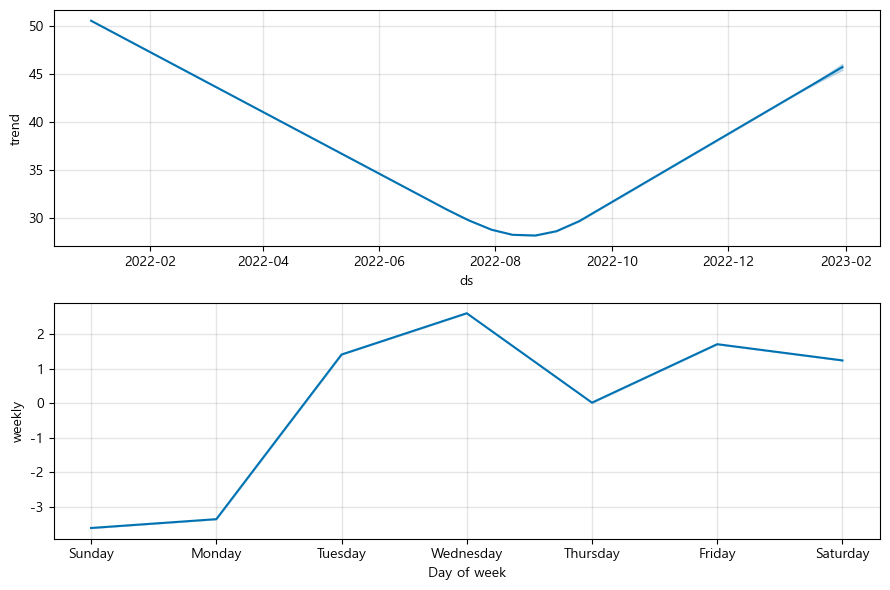

In [119]:
# 트렌드와 휴일효과 시각화
p=p_model.plot_components(forecast)

In [122]:
forecast.loc[forecast['ds']=='2023-01-15',['yhat_lower','yhat_upper']]

,yhat_lower,yhat_upper
379,18.499791,62.686088
